# 07. 데이터 정제 - 결측데이터 제거


In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({'sex':['M','F',np.nan , 'M','F'],
            'score':[5,4,3,4,np.nan]})

pd.isna(df).sum()   # 결측치 확인


df.dropna(subset='score') # 결측치 제거


df_nomiss = df.dropna(subset=['score','sex']) # 여러 열의 결측치 제거


df_nomiss

# 결측치를 제거하지않고 평균값으로 치환하는것도 가능하다
exam = pd.read_csv('exam.csv')
exam.loc[[2,7,10],['math']] = np.nan
math_average = exam['math'].mean()
exam['math'] = exam['math'].fillna(math_average)    #결측치에 평균값을 대입
exam

,id,nclass,math,english,science
0,1,1,50.000000,98,50
1,2,1,60.000000,97,60
2,3,1,55.823529,86,78
3,4,1,30.000000,98,58
4,5,2,25.000000,80,65
5,6,2,50.000000,89,98
6,7,2,80.000000,90,45
7,8,2,55.823529,78,25
8,9,3,20.000000,98,15
9,10,3,50.000000,98,45


hwy의 결측치 : 0
hwy의 결측치가 있나? 0


<Axes: xlabel='drv'>

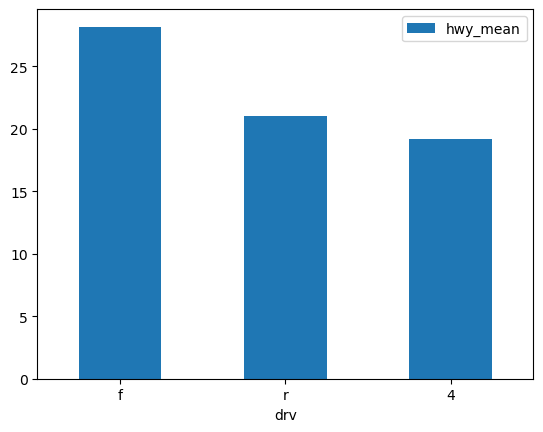

In [16]:
# 혼자서해보기
mpg = pd.read_csv('mpg.csv')
# q1. drv별로 hwy평균이 어떻게 다른지 알아보려한다. 하지만 분석을 하기전에 결측치가 있는지 확인하라. 있다면 몇개있는지도 확인하라
print(f'hwy의 결측치 : {mpg['hwy'].isna().sum()}')
mpg.groupby('drv').agg(hwy_mean=('hwy','mean')).sort_values('hwy_mean',ascending=False)

# q2. hwy의 결측치를 제거하고 어떤 구동방식의 hwy평균이 높은지 알아보라. 하나의 구문으로
print(f'hwy의 결측치가 있나? {pd.isna(mpg['hwy']).sum()}')
drv_hwy = mpg.dropna(subset=['hwy']).groupby('drv').agg(hwy_mean = ('hwy','mean')).sort_values('hwy_mean',ascending=False)
drv_hwy.plot.bar(rot=0)


## 07-2. 이상치 데이터 정제하기

In [ ]:
# 존재할수없는 값이 데이터가 들어갔을때 이상치 데이터라고 한다
df = pd.DataFrame({'sex':[1,2,1,3,2,1],
                   'score':[5,4,3,4,2,6]})
df
# sex는 1,2 , score는 1-5점까지 뿐이다. 하지만 3, 6이 들어가있다. 처리해야한다

# 이상데이터는 결측처리
df['sex'] = np.where( (df['sex'] > 2) | (df['sex'] < 1), np.nan, df['sex'])
df['score'] = np.where((df['score'] > 5) | (df['score'] < 1), np.nan, df['score'])
df

# 주의할점. np.where()함수는 반환값중 문자가 포함되면 np.nan을 제대로 인식하지못한다. 
# 이 경우 np.nan이 아닌 다른 문자열을 지정한후 예)'etc' 
# 다음줄에서 df.replace('etc',np.nan)이런식으로 사용

,sex,score
0,1.0,5.0
1,2.0,4.0
2,1.0,3.0
3,NaN,4.0
4,2.0,2.0
5,1.0,NaN


In [40]:
# 극단적인 값 제거
import seaborn as sns
mpg = pd.read_csv('mpg.csv')

mpg['hwy'].describe()

#극단치값 구하기
pct25 = mpg['hwy'].quantile(.25)
pct75 = mpg['hwy'].quantile(.75)
iqr = pct75 - pct25

extreme_low = pct25 - (iqr * 1.5)
extreme_high = pct75 + (iqr * 1.5)

# 극단값은 np.nan처리
mpg['hwy'] = np.where((mpg['hwy'] > extreme_high) | (mpg['hwy'] < extreme_low) , np.nan, mpg['hwy'])

# 극단값 제외하고 hwy의 평균을 구한다
mpg.dropna(subset=['hwy']).groupby('drv').agg(hwy_mean =('hwy','mean'))
#

,hwy_mean
drv,
4,19.174757
f,27.728155
r,21.000000


In [ ]:
# 혼자서 해보기

# 극단값을 의도적으로 삽입한다
mpg = pd.read_csv('mpg.csv')
mpg.loc[[9,13,57,92],'drv'] = 'k'
mpg.loc[[28,42,128,202],'cty'] = [3,4,39,42]

# q1. drv에 이상치가 있는지 확인. 결측처리후 이상치가 사라졌는지 확인
mpg['drv']  = np.where(mpg['drv'].isin(['f','r','4']), mpg['drv'],np.nan)
print(f'결측치가 {int(mpg['drv'].isna().sum())} 개 있습니다')

mpg = mpg.dropna(subset=['drv'])
print(f'결측치가 {int(mpg['drv'].isna().sum())} 개 있습니다')

결측치가 4 개 있습니다
결측치가 0 개 있습니다


<Axes: ylabel='cty'>

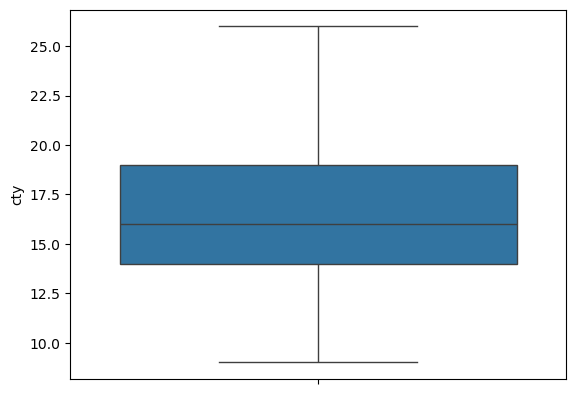

In [ ]:
#q2. 상자그림을 이용해 cty가 이상치가 있는지 확인. 상자그림 기준으로 결측처리후 다시 상자그림을 그린다
mpg = pd.read_csv('mpg.csv')

pct25 = mpg['cty'].quantile(.25)
pct75 = mpg['cty'].quantile(.75)
iqr = pct75 - pct25
extreme_low = pct25  - (iqr * 1.5)
extreme_high = pct75 + (iqr* 1.5)

mpg['cty'] = np.where((mpg['cty'] > extreme_high) | (mpg['cty'] < extreme_low) , np.nan, mpg['cty'])
mpg['cty'].isna().sum()

mpg = mpg.dropna(subset=['cty'])

sns.boxplot(data=mpg, y='cty')


In [80]:
# q3 
a = mpg.dropna(subset=['drv','cty']).groupby('drv').agg(cty_mean = ('cty','mean')).sort_values('cty_mean',ascending=False)
a

,cty_mean
drv,
f,19.445545
4,14.330097
r,14.080000
